# TwitterAPI.io archive AI-risk sentiment event study

Separate optional analysis of a query-defined X-post sample for September 8-30, 2026. It uses TwitterAPI.io Advanced Search and mirrors the original sentiment, basket-return, chart, risk-framing comparison, and one-lag Granger workflow. Search calls are capped to control third-party API-credit usage. The notebook must not be interpreted until the provider returns posts; no X-post results are folded into REPORT.md unless this run succeeds.

In [1]:
from pathlib import Path
import json, os, re, time
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import yfinance as yf
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from statsmodels.tsa.stattools import grangercausalitytests

START, END = '2026-09-08', '2026-10-01'
RAW = Path('data/raw'); RAW.mkdir(parents=True, exist_ok=True)
QUERY_TYPE = 'Top'  # ranking provides a window-wide query-defined sample within the collection cap
CACHE = RAW / f'twitterapiio_advanced_search_{QUERY_TYPE.lower()}_{START}_{END}.json'
TICKERS = ['NVDA', 'META', 'AMZN', 'GOOGL', 'MSFT', 'AVGO', 'TSM']
MAX_PAGES, MAX_POSTS = 100, 2000
start_epoch = int(pd.Timestamp(START, tz='UTC').timestamp()); end_epoch = int(pd.Timestamp(END, tz='UTC').timestamp())
QUERY = ('(\"Evan Hubinger\" OR \"Jacob Coxon\" OR Anthropic) (\"AI risk\" OR \"AI safety\" OR \"existential risk\" OR alignment) lang:en -filter:retweets ' f'since_time:{start_epoch} until_time:{end_epoch}')

secret_file = Path('secrets/twitterapi_io_key.txt')
api_key = secret_file.read_text(encoding='utf-8').strip() if secret_file.exists() else os.getenv('TWITTERAPI_IO_KEY', '').strip()
if not api_key: raise RuntimeError('Set TWITTERAPI_IO_KEY or create secrets/twitterapi_io_key.txt with only the API key.')

def fetch_archive(query, key):
    tweets, cursor = [], ''
    for _ in range(MAX_PAGES):
        response = requests.get('https://api.twitterapi.io/twitter/tweet/advanced_search', headers={'X-API-Key': key}, params={'query': query, 'queryType': QUERY_TYPE, 'cursor': cursor}, timeout=60)
        if response.status_code in (401, 403): raise RuntimeError(f'TwitterAPI.io returned {response.status_code}: check API key and account access.')
        if response.status_code in (402, 429): raise RuntimeError(f'TwitterAPI.io returned {response.status_code}: check credits or rate limits.')
        response.raise_for_status(); page = response.json(); batch = page.get('tweets', [])
        tweets.extend(batch)
        if len(tweets) >= MAX_POSTS or not page.get('has_next_page') or not batch: break
        cursor = page.get('next_cursor', '')
        if not cursor: break
        time.sleep(.2)
    return {'tweets': tweets[:MAX_POSTS], 'query': query, 'start': START, 'end_exclusive': END, 'pages_cap': MAX_PAGES, 'posts_cap': MAX_POSTS}

if CACHE.exists(): payload = json.loads(CACHE.read_text(encoding='utf-8')); print(f'Using cache: {CACHE}')
else:
    payload = fetch_archive(QUERY, api_key); CACHE.write_text(json.dumps(payload, indent=2), encoding='utf-8')
    print(f'Cached {len(payload["tweets"])} posts to {CACHE}')

Using cache: data/raw/twitterapiio_advanced_search_top_2026-09-08_2026-10-01.json


Unique returned posts: 1086; aligned trading observations: 16
Cumulative basket return: 2.88%; SPY: -0.19%


,basket_return,basket_excess_return,posts,compound,risk_intensity,engagement
Date,,,,,,
2026-09-09,-0.0016,0.0031,104.0,-0.0834,-0.0152,138056.0
2026-09-10,-0.0084,-0.0024,33.0,-0.2949,-0.0020,41770.0
2026-09-11,0.0091,0.0006,17.0,0.0494,0.0003,1614.0
2026-09-14,-0.0077,-0.0032,19.0,0.0732,-0.0076,26260.0
2026-09-15,-0.0090,-0.0044,24.0,0.2585,-0.0095,56740.0
2026-09-16,-0.0006,0.0038,3.0,0.1505,-0.0097,67.0
2026-09-17,0.0200,0.0087,15.0,-0.0752,-0.0034,24735.0
2026-09-18,0.0052,0.0039,6.0,0.3364,-0.0114,8490.0
2026-09-21,0.0315,0.0161,4.0,0.3087,-0.0051,10584.0


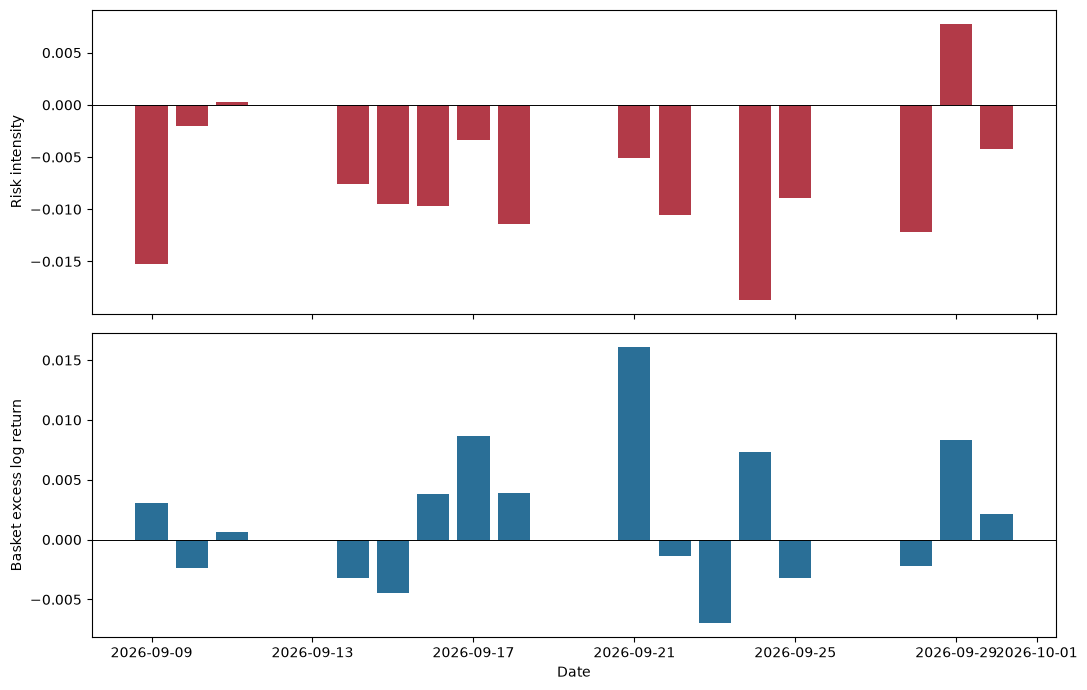

compound -> next-day basket excess return: p=0.2010, usable N=16
risk_intensity -> next-day basket excess return: p=0.9117, usable N=16
posts -> next-day basket excess return: p=0.8876, usable N=16


In [2]:
posts = pd.DataFrame(payload.get('tweets', []))
if posts.empty: raise RuntimeError('The query returned no posts; inspect query coverage before interpreting results.')
posts['createdAt'] = pd.to_datetime(posts['createdAt'], utc=True, format='mixed'); posts['date'] = posts['createdAt'].dt.tz_convert('America/New_York').dt.normalize().dt.tz_localize(None); posts = posts[(posts['date'] >= pd.Timestamp(START)) & (posts['date'] < pd.Timestamp(END))].copy(); posts['text'] = posts['text'].fillna('')
analyzer = SentimentIntensityAnalyzer()
NEG = re.compile(r'\b(risk|risks|danger|dangerous|doom|kill|killed|death|extinction|existential|catastroph(?:e|ic)|threat|harm|misalign(?:ed|ment)?)\b', re.I); POS = re.compile(r'\b(safe|safety|benefit|beneficial|progress|solution|solve|alignment|aligned)\b', re.I)
def risk_intensity(text):
    words = re.findall(r"[A-Za-z']+", text); return (len(NEG.findall(text))-len(POS.findall(text)))/max(len(words),1)
posts['compound'] = posts['text'].map(lambda t: analyzer.polarity_scores(t)['compound']); posts['risk_intensity'] = posts['text'].map(risk_intensity)
posts['engagement'] = posts[['likeCount','replyCount','retweetCount','quoteCount']].fillna(0).sum(axis=1)
daily = posts.groupby('date').agg(posts=('id','count'), compound=('compound','mean'), risk_intensity=('risk_intensity','mean'), engagement=('engagement','sum'))
prices = yf.download(TICKERS+['SPY'], start=START, end=END, auto_adjust=True, progress=False)['Close']; returns = np.log(prices/prices.shift(1)).dropna(); returns['basket_return'] = returns[TICKERS].mean(axis=1); returns['basket_excess_return'] = returns['basket_return']-returns['SPY']
panel = returns[['basket_return','basket_excess_return']].join(daily,how='left').fillna({'posts':0,'compound':0,'risk_intensity':0,'engagement':0})
print(f'Unique returned posts: {posts.id.nunique()}; aligned trading observations: {len(panel)}')
print('Cumulative basket return: {:.2%}; SPY: {:.2%}'.format(np.exp(returns.basket_return.sum())-1,np.exp(returns.SPY.sum())-1)); display(panel.round(4))
fig, ax = plt.subplots(2,1,figsize=(11,7),sharex=True); ax[0].bar(panel.index,panel.risk_intensity,color='#b23a48'); ax[0].axhline(0,color='black',lw=.7); ax[0].set_ylabel('Risk intensity'); ax[1].bar(panel.index,panel.basket_excess_return,color='#2a6f97'); ax[1].axhline(0,color='black',lw=.7); ax[1].set_ylabel('Basket excess log return'); ax[1].set_xlabel('Date'); fig.tight_layout(); plt.show()
def granger_p(driver):
    sample=panel[['basket_excess_return',driver]].dropna()
    if len(sample)<10 or sample[driver].nunique()<2: return np.nan,len(sample)
    return grangercausalitytests(sample,maxlag=1)[1][0]['ssr_ftest'][1],len(sample)
for driver in ['compound','risk_intensity','posts']:
    p,n=granger_p(driver); print(f'{driver} -> next-day basket excess return: p={p:.4f}, usable N={n}')

In [3]:
# Broad-AI comparison sample for the risk-framing test. This intentionally uses a capped query-defined sample, not a census.
BROAD_CACHE = RAW / f'twitterapiio_broad_ai_{QUERY_TYPE.lower()}_{START}_{END}.json'
BROAD_QUERY = '(\"artificial intelligence\" OR AI) lang:en -filter:retweets ' f'since_time:{start_epoch} until_time:{end_epoch}'
if BROAD_CACHE.exists(): broad_payload = json.loads(BROAD_CACHE.read_text(encoding='utf-8')); print(f'Using broad-AI cache: {BROAD_CACHE}')
else:
    broad_payload = fetch_archive(BROAD_QUERY, api_key); BROAD_CACHE.write_text(json.dumps(broad_payload, indent=2), encoding='utf-8')
    print(f'Cached {len(broad_payload["tweets"])} broad-AI posts to {BROAD_CACHE}')
broad = pd.DataFrame(broad_payload.get('tweets', []))
if broad.empty: raise RuntimeError('The broad-AI comparison query returned no posts; do not infer a framing differential.')
broad['createdAt'] = pd.to_datetime(broad['createdAt'], utc=True, format='mixed'); broad['date'] = broad['createdAt'].dt.tz_convert('America/New_York').dt.normalize().dt.tz_localize(None); broad = broad[(broad['date'] >= pd.Timestamp(START)) & (broad['date'] < pd.Timestamp(END))].copy(); broad['text'] = broad['text'].fillna(''); broad['compound'] = broad['text'].map(lambda t: analyzer.polarity_scores(t)['compound']); broad['risk_intensity'] = broad['text'].map(risk_intensity)
comparison = pd.DataFrame({'event/risk query': [len(posts), posts.compound.mean(), posts.risk_intensity.mean()], 'broad-AI query': [len(broad), broad.compound.mean(), broad.risk_intensity.mean()]}, index=['posts returned', 'mean VADER compound', 'mean risk intensity'])
comparison['difference'] = comparison['event/risk query'] - comparison['broad-AI query']
comparison.round(4)

Using broad-AI cache: data/raw/twitterapiio_broad_ai_top_2026-09-08_2026-10-01.json


,event/risk query,broad-AI query,difference
posts returned,1086.0000,1722.0000,-636.0000
mean VADER compound,0.1640,0.1435,0.0205
mean risk intensity,-0.0074,0.0007,-0.0080


In [4]:
p_results = {driver: granger_p(driver)[0] for driver in ['compound', 'risk_intensity', 'posts']}
print('## Results-based interpretation')
print(f'The event/risk query returned {len(posts)} posts; the broad-AI comparison returned {len(broad)}. Mean compound sentiment was {posts.compound.mean():+.3f} versus {broad.compound.mean():+.3f}; mean risk intensity was {posts.risk_intensity.mean():+.4f} versus {broad.risk_intensity.mean():+.4f}.')
print(f'The selected AI basket compounded {np.exp(returns.basket_return.sum())-1:+.2%} versus {np.exp(returns.SPY.sum())-1:+.2%} for SPY across {len(panel)} aligned trading observations.')
print('One-lag Granger p-values for next-day basket excess return: ' + ', '.join(f'{k}={v:.4f}' for k,v in p_results.items()) + '.')
tone = 'more positive' if posts.compound.mean() > broad.compound.mean() else 'more negative' if posts.compound.mean() < broad.compound.mean() else 'equal in mean VADER tone'
risk = 'lower' if posts.risk_intensity.mean() < broad.risk_intensity.mean() else 'higher' if posts.risk_intensity.mean() > broad.risk_intensity.mean() else 'equal'
print(f'Descriptively, the event/risk sample was {tone} and had {risk} lexicon risk intensity than the broad-AI sample. This is a query-defined framing differential, not proof of general social-media bias. These low-power bivariate tests do not establish causality.')

## Results-based interpretation
The event/risk query returned 1086 posts; the broad-AI comparison returned 1722. Mean compound sentiment was +0.164 versus +0.144; mean risk intensity was -0.0074 versus +0.0007.
The selected AI basket compounded +2.88% versus -0.19% for SPY across 16 aligned trading observations.
One-lag Granger p-values for next-day basket excess return: compound=0.2010, risk_intensity=0.9117, posts=0.8876.
Descriptively, the event/risk sample was more positive and had lower lexicon risk intensity than the broad-AI sample. This is a query-defined framing differential, not proof of general social-media bias. These low-power bivariate tests do not establish causality.


## Interpretation and reproducibility guardrails

The notebook provides the required social-data trend, comparison sample, AI-equity basket, one-lag Granger diagnostic, and risk-framing comparison when both queries return data. Treat returned posts as a query-defined third-party-provider sample, not a complete or independently validated census of X. Search ranking, deleted posts, date/language filters, query terms, the configured collection caps, and the VADER/lexicon proxy affect the measure. A negative event-versus-broad difference is descriptive evidence of risk framing in these samples, not proof of platform-wide media bias. Granger results are predictive-lag diagnostics, not proof that post sentiment caused stock returns.

Sources: TwitterAPI.io Advanced Search documentation, Yahoo Finance adjusted closes through yfinance, and the methodological references cited in REPORT.md. Raw responses are cached under ignored data/raw; the API key is read only from an ignored local file or environment variable.